In [ ]:
import sys
from line_profiler import profile
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/EM_analyzer')
import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import jax.numpy as jnp
from plot.plot_2D import plot_2D_field
from rotate_3D import Rotation

3
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2)]


In [2]:
x_coordinate = jnp.linspace(-10, 10, 1001)
y_coordinate = jnp.linspace(-10, 10, 1001)
z_coordinate=jnp.array([0])  #单层
X, Y, Z = jnp.meshgrid(x_coordinate, y_coordinate, z_coordinate, indexing='ij')
Ax = jnp.exp(-0.1 * (X**2 + Y**2)) * jnp.cos(5 * X) * jnp.cos(3 * Y)
Ay = jnp.exp(-0.1 * (X**2 + Y**2)) * jnp.sin(5 * X) * jnp.sin(3 * Y)
Az = jnp.zeros_like(Ax)

In [10]:
rotation=Rotation(psi=np.pi/4)

Rotation with angles (phi, psi, theta)=(0.0, 0.7853981633974483, 0.0) radians initialized.


In [5]:
A1=rotation.rotate(jnp.stack([Ax, Ay, Az], axis=0), x0_coordinate=x_coordinate, y0_coordinate=y_coordinate, z0_coordinate=z_coordinate, x1_coordinate=x_coordinate, y1_coordinate=y_coordinate, z1_coordinate=z_coordinate)

In [6]:
print(A1.shape)

(3, 10001, 10001, 1)


Input field shape: (3, 10001, 10001, 1), Output field shape: (3, 10001, 10001, 1)
∬|Field|^2×dr=7.853981629992852
Input field integral: 7.853981629992852
∬|Field|^2×dr=7.8538026045847324
Output field integral: 7.8538026045847324
Integral ratio I1/I0: 0.9999772057770755
figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='x', ylabel='y'>,
 'ax_panel_top': <Axes: xlabel='x', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='y'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x1481ac386e40>}

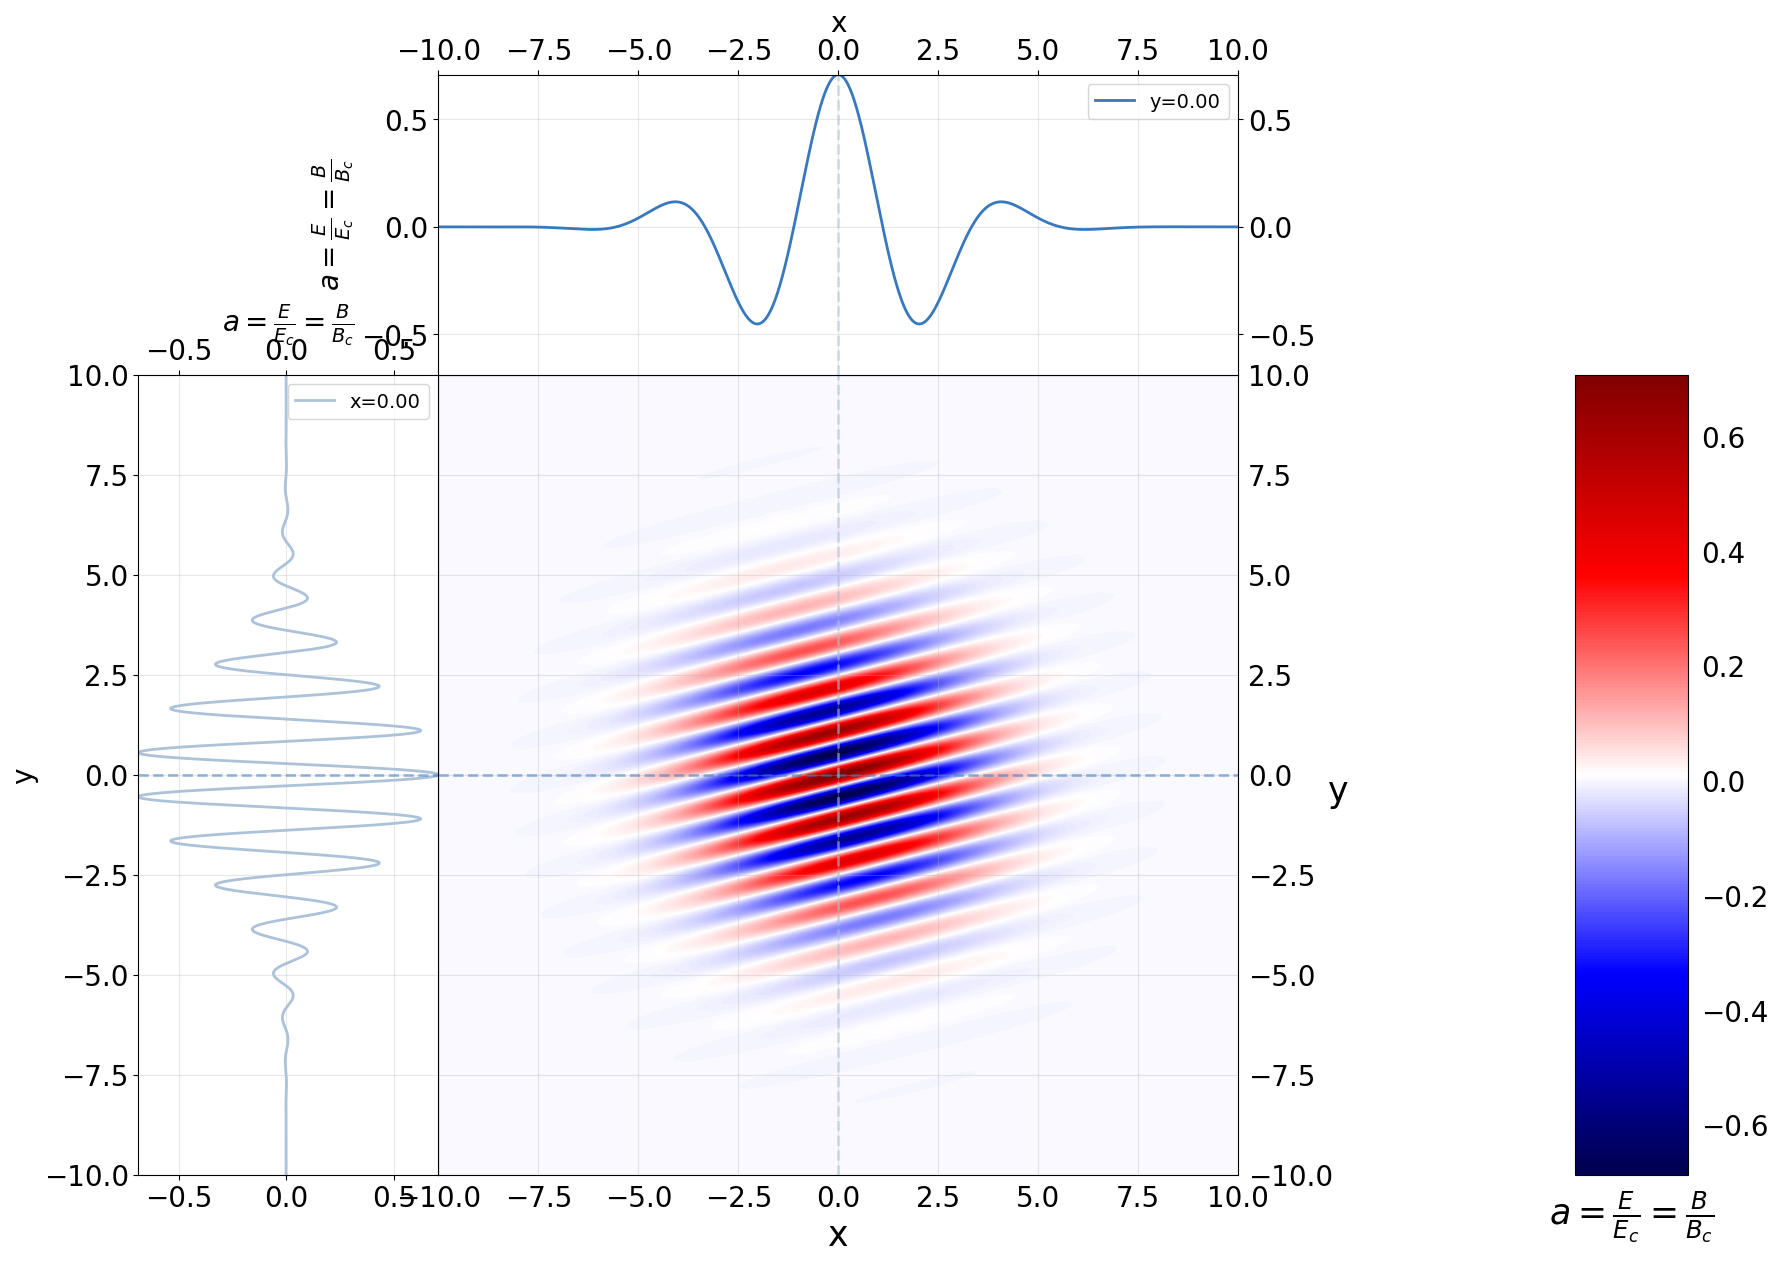

In [7]:
plot_2D_field(field=A1[0, :, :, 0], x_coordinate=x_coordinate, y_coordinate=y_coordinate, xlabel='x', ylabel='y')

In [6]:
f0=jnp.exp(-0.1 * (0.5*X**2+3*Y**2)**2)

figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='x', ylabel='y'>,
 'ax_panel_top': <Axes: xlabel='x', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='y'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14693c16a0d0>}

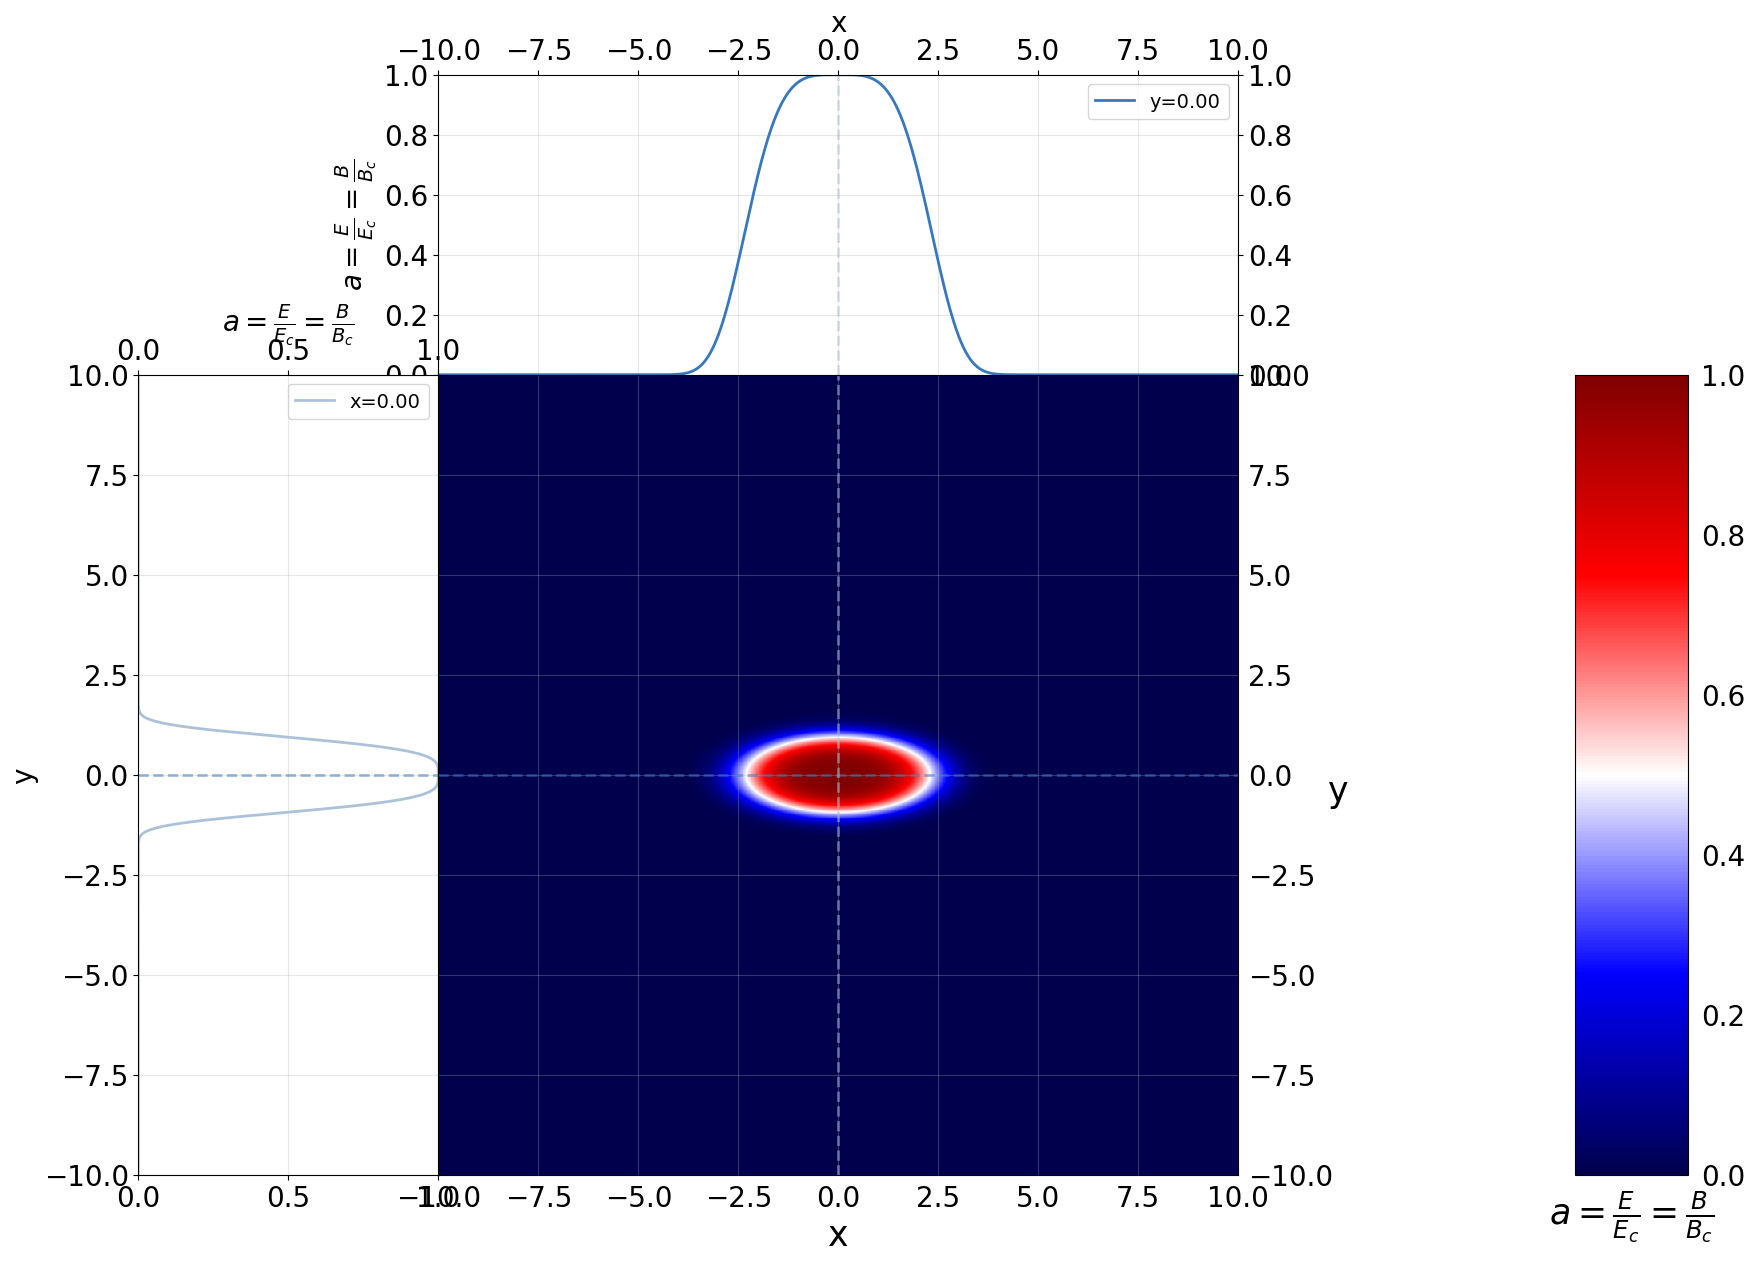

In [7]:
plot_2D_field(field=f0[:, :, 0], x_coordinate=x_coordinate, y_coordinate=y_coordinate, xlabel='x', ylabel='y')

In [11]:
f1=rotation.rotate(f0, x0_coordinate=x_coordinate, y0_coordinate=y_coordinate, z0_coordinate=z_coordinate, x1_coordinate=x_coordinate, y1_coordinate=y_coordinate, z1_coordinate=z_coordinate, type='scalar')

Input field shape: (1001, 1001, 1), Output field shape: (1001, 1001, 1)
∬|Field|^2×dr=5.083164752420245
Input field integral: 5.083164752420245
∬|Field|^2×dr=5.082566469104803
Output field integral: 5.082566469104803
Integral ratio I1/I0: 0.999882301018247


figure size= [18.5 14. ] inch
ax_main position= Bbox(x0=0.24324324324324326, y0=0.10714285714285714, x1=0.6756756756756757, y1=0.6785714285714285)


{'fig': <Figure size 1850x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='x', ylabel='y'>,
 'ax_panel_top': <Axes: xlabel='x', ylabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$'>,
 'ax_panel_left': <Axes: xlabel='$a=\\frac{E}{E_c}=\\frac{B}{B_c}$', ylabel='y'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14695c3e8640>}

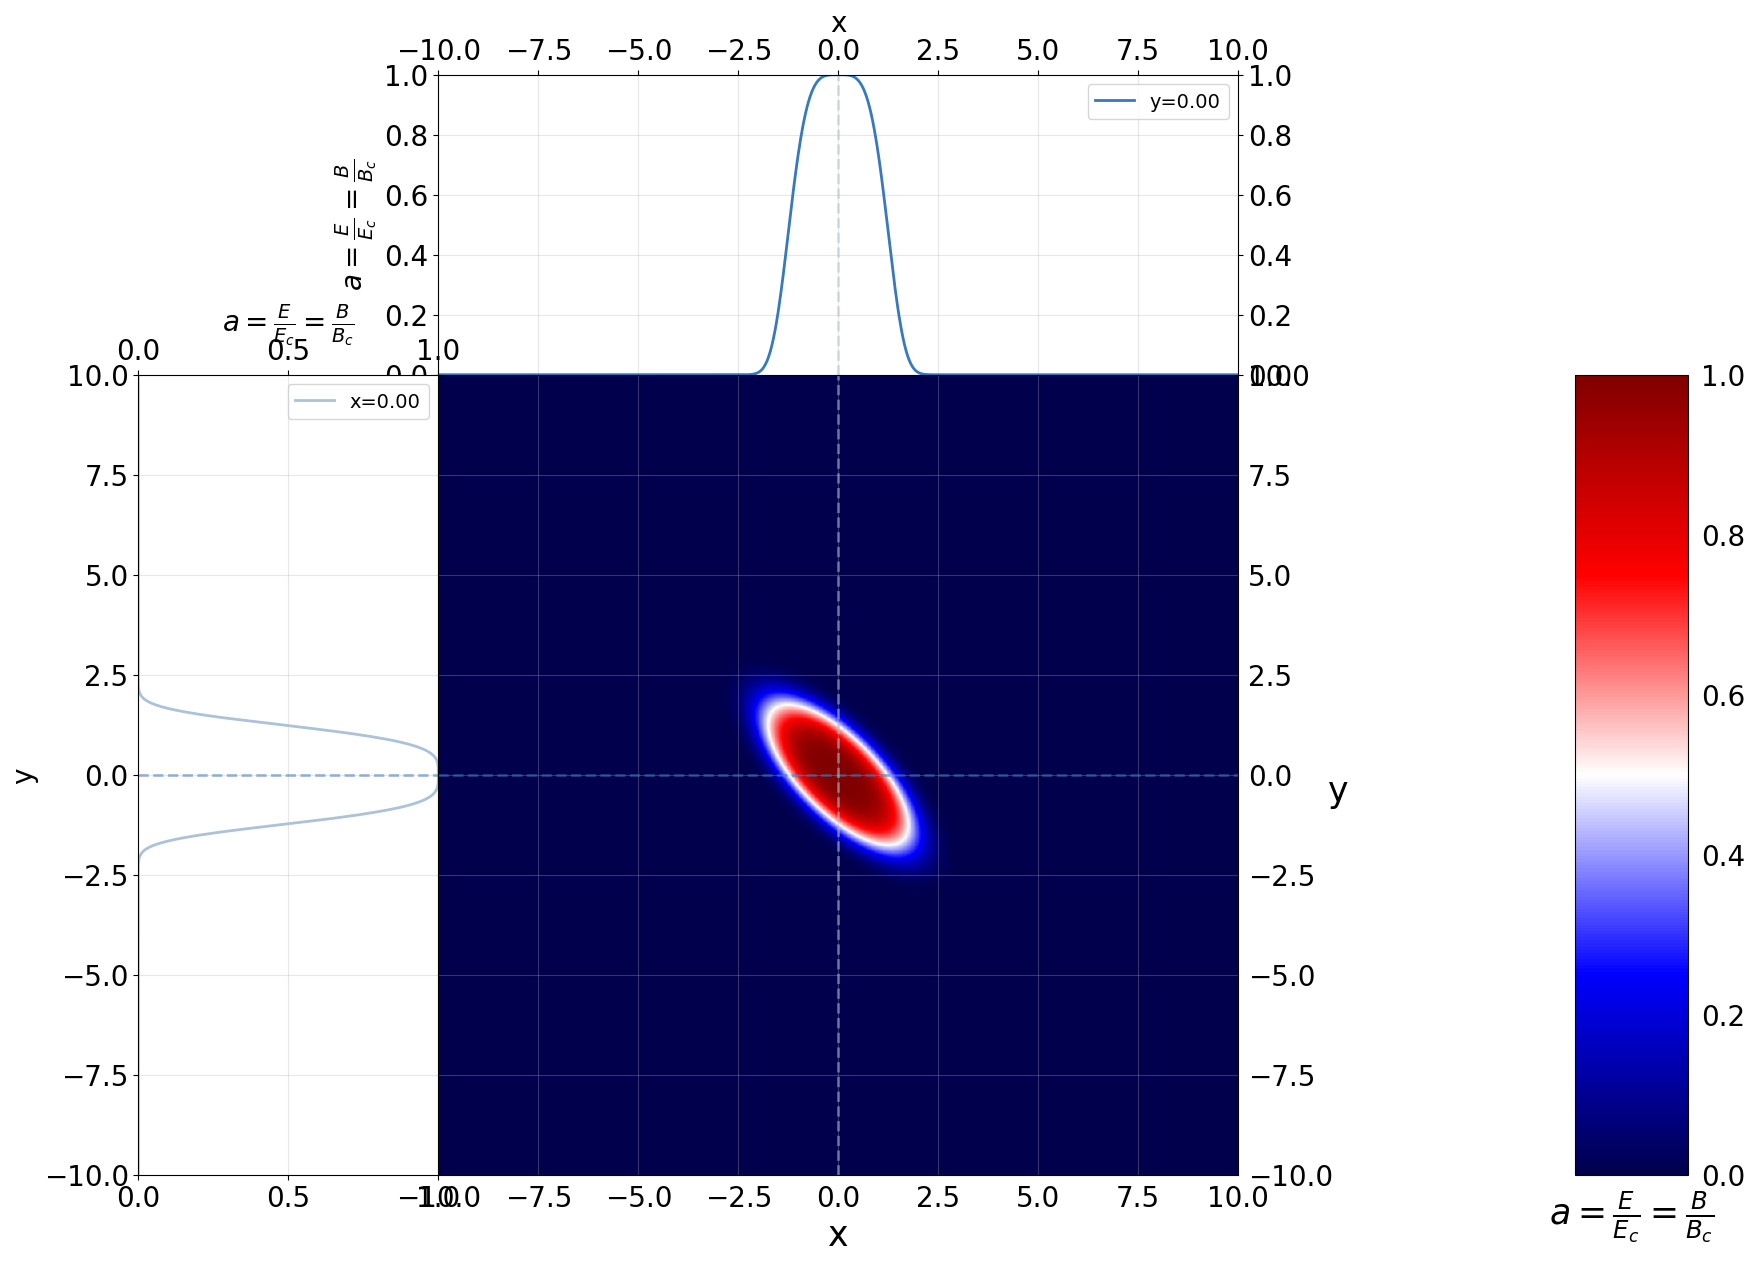

In [12]:
plot_2D_field(field=f1[:, :, 0], x_coordinate=x_coordinate, y_coordinate=y_coordinate, xlabel='x', ylabel='y')   